In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}"
)


current_directory = Path.cwd().resolve()
PROJECT_ROOT = None

for directory in [current_directory, *current_directory.parents]:
    feature_file = (
        directory
        / "data"
        / "processed"
        / "hcp_ml_features.csv"
    )

    if feature_file.exists():
        PROJECT_ROOT = directory
        break


if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/processed/hcp_ml_features.csv"
    )


FEATURE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hcp_ml_features.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


hcp_features = pd.read_csv(
    FEATURE_PATH,
    parse_dates=["last_call_date"]
)


print("Project root:", PROJECT_ROOT)
print("Feature rows:", len(hcp_features))
print(
    "Unique HCPs:",
    hcp_features["hcp_id"].nunique()
)

display(hcp_features.head())

Project root: D:\rxguide\rxguide-hcp-analytics
Feature rows: 500
Unique HCPs: 500


,hcp_id,hcp_name,specialty,segment,territory,region,total_prescriptions,total_units_dispensed,average_monthly_prescriptions,active_months,product_breadth,total_calls,total_samples_received,average_call_duration,called_product_breadth,last_call_date,prescriptions_per_call,days_since_last_call,no_call_flag,recent_3m_units,previous_3m_units,recent_growth_pct
0,H0001,Dr. HCP_0001,Endocrinologist,B,North-1,North,91,3711,9.10,10,5,27,99,21.56,5,2026-03-30,3.37,1,0,958,1067,-10.22
1,H0002,Dr. HCP_0002,Pulmonologist,C,North-1,North,61,2439,6.10,10,5,55,238,20.78,5,2026-03-28,1.11,3,0,864,846,2.13
2,H0003,Dr. HCP_0003,Endocrinologist,C,Central-1,Central,89,3217,8.90,10,5,40,155,20.35,5,2026-03-22,2.23,9,0,874,982,-11.00
3,H0004,Dr. HCP_0004,Endocrinologist,B,West-2,West,44,1809,4.40,10,5,14,58,21.07,5,2026-02-23,3.14,36,0,641,299,114.38
4,H0005,Dr. HCP_0005,Neurologist,A,Central-2,Central,29,1179,2.90,10,4,6,26,22.00,3,2026-03-04,4.83,27,0,411,368,11.68


In [3]:
candidate_features = [
    "total_units_dispensed",
    "recent_growth_pct",
    "total_calls",
    "prescriptions_per_call",
    "product_breadth",
    "days_since_last_call",
]


model_data = hcp_features[
    ["hcp_id", "hcp_name", *candidate_features]
].copy()


feature_review = pd.DataFrame(
    {
        "data_type": (
            model_data[candidate_features]
            .dtypes
            .astype(str)
        ),
        "missing_values": (
            model_data[candidate_features]
            .isna()
            .sum()
        ),
        "unique_values": (
            model_data[candidate_features]
            .nunique()
        ),
        "minimum": (
            model_data[candidate_features]
            .min()
        ),
        "maximum": (
            model_data[candidate_features]
            .max()
        ),
        "mean": (
            model_data[candidate_features]
            .mean()
        ),
    }
).round(2)


print("Model rows:", len(model_data))

display(feature_review)
display(model_data.head())

Model rows: 500


,data_type,missing_values,unique_values,minimum,maximum,mean
total_units_dispensed,int64,0,475,0.00,"12,996.00","2,881.03"
recent_growth_pct,float64,23,457,-100.00,800.00,11.79
total_calls,int64,0,75,0.00,88.00,22.77
prescriptions_per_call,float64,56,312,0.58,17.50,3.99
product_breadth,int64,0,6,0.00,5.00,4.36
days_since_last_call,int64,0,70,0.00,304.00,49.04


,hcp_id,hcp_name,total_units_dispensed,recent_growth_pct,total_calls,prescriptions_per_call,product_breadth,days_since_last_call
0,H0001,Dr. HCP_0001,3711,-10.22,27,3.37,5,1
1,H0002,Dr. HCP_0002,2439,2.13,55,1.11,5,3
2,H0003,Dr. HCP_0003,3217,-11.00,40,2.23,5,9
3,H0004,Dr. HCP_0004,1809,114.38,14,3.14,5,36
4,H0005,Dr. HCP_0005,1179,11.68,6,4.83,4,27


In [4]:
missing_efficiency_review = hcp_features.loc[
    hcp_features["prescriptions_per_call"].isna(),
    [
        "hcp_id",
        "total_prescriptions",
        "total_units_dispensed",
        "total_calls",
        "prescriptions_per_call",
        "days_since_last_call",
        "no_call_flag",
    ],
].copy()


missing_growth_review = hcp_features.loc[
    hcp_features["recent_growth_pct"].isna(),
    [
        "hcp_id",
        "recent_3m_units",
        "previous_3m_units",
        "recent_growth_pct",
        "total_units_dispensed",
    ],
].copy()


print(
    "Missing prescriptions-per-call rows:",
    len(missing_efficiency_review)
)

print(
    "Of these, HCPs with zero calls:",
    (
        missing_efficiency_review["total_calls"] == 0
    ).sum()
)

print(
    "Of these, HCPs with no_call_flag = 1:",
    (
        missing_efficiency_review["no_call_flag"] == 1
    ).sum()
)


print(
    "\nDays-since-last-call values for these HCPs:"
)

display(
    missing_efficiency_review[
        "days_since_last_call"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("days_since_last_call")
    .reset_index(name="hcp_count")
)


print(
    "\nMissing recent-growth rows:",
    len(missing_growth_review)
)

print(
    "Of these, previous 3-month units equal to zero:",
    (
        missing_growth_review["previous_3m_units"] == 0
    ).sum()
)


display(missing_efficiency_review.head())

display(missing_growth_review.head())

Missing prescriptions-per-call rows: 56
Of these, HCPs with zero calls: 56
Of these, HCPs with no_call_flag = 1: 56

Days-since-last-call values for these HCPs:


,days_since_last_call,hcp_count
0,304,56



Missing recent-growth rows: 23
Of these, previous 3-month units equal to zero: 23


,hcp_id,total_prescriptions,total_units_dispensed,total_calls,prescriptions_per_call,days_since_last_call,no_call_flag
13,H0014,10,469,0,NaN,304,1
21,H0022,7,234,0,NaN,304,1
32,H0033,0,0,0,NaN,304,1
46,H0047,0,0,0,NaN,304,1
50,H0051,0,0,0,NaN,304,1


,hcp_id,recent_3m_units,previous_3m_units,recent_growth_pct,total_units_dispensed
32,H0033,0,0,NaN,0
46,H0047,0,0,NaN,0
50,H0051,0,0,NaN,0
59,H0060,0,0,NaN,0
91,H0092,0,0,NaN,0


In [5]:
growth_missing_cases = missing_growth_review.copy()


growth_missing_cases["growth_case"] = np.where(
    growth_missing_cases["recent_3m_units"] == 0,
    "No activity in either period",
    "New activity from zero base",
)


growth_case_summary = (
    growth_missing_cases
    .groupby("growth_case")
    .agg(
        hcp_count=("hcp_id", "count"),
        minimum_recent_units=("recent_3m_units", "min"),
        maximum_recent_units=("recent_3m_units", "max"),
        total_recent_units=("recent_3m_units", "sum"),
    )
    .reset_index()
)


display(growth_case_summary)

display(
    growth_missing_cases
    .sort_values(
        "recent_3m_units",
        ascending=False
    )
)

,growth_case,hcp_count,minimum_recent_units,maximum_recent_units,total_recent_units
0,New activity from zero base,5,25,159,309
1,No activity in either period,18,0,0,0


,hcp_id,recent_3m_units,previous_3m_units,recent_growth_pct,total_units_dispensed,growth_case
300,H0301,159,0,NaN,245,New activity from zero base
455,H0456,59,0,NaN,304,New activity from zero base
451,H0452,40,0,NaN,68,New activity from zero base
179,H0180,26,0,NaN,75,New activity from zero base
425,H0426,25,0,NaN,66,New activity from zero base
46,H0047,0,0,NaN,0,No activity in either period
32,H0033,0,0,NaN,0,No activity in either period
187,H0188,0,0,NaN,0,No activity in either period
91,H0092,0,0,NaN,0,No activity in either period
59,H0060,0,0,NaN,0,No activity in either period


In [6]:
model_data = hcp_features.copy()


model_data["prescription_momentum"] = (
    np.log1p(model_data["recent_3m_units"])
    - np.log1p(model_data["previous_3m_units"])
)


covered_hcp_median_efficiency = (
    model_data.loc[
        model_data["total_calls"] > 0,
        "prescriptions_per_call"
    ]
    .median()
)


model_data["prescriptions_per_call"] = (
    model_data["prescriptions_per_call"]
    .fillna(covered_hcp_median_efficiency)
)


clustering_features = [
    "total_units_dispensed",
    "prescription_momentum",
    "total_calls",
    "prescriptions_per_call",
    "product_breadth",
    "days_since_last_call",
]


print(
    "Median prescriptions per call:",
    round(covered_hcp_median_efficiency, 2)
)

print(
    "Remaining missing values:",
    model_data[clustering_features]
    .isna()
    .sum()
    .sum()
)


display(
    model_data[
        [
            "hcp_id",
            "recent_3m_units",
            "previous_3m_units",
            "recent_growth_pct",
            "prescription_momentum",
            "total_calls",
            "prescriptions_per_call",
        ]
 
    ].head(10)
)

Median prescriptions per call: 3.45
Remaining missing values: 0


,hcp_id,recent_3m_units,previous_3m_units,recent_growth_pct,prescription_momentum,total_calls,prescriptions_per_call
0,H0001,958,1067,-10.22,-0.11,27,3.37
1,H0002,864,846,2.13,0.02,55,1.11
2,H0003,874,982,-11.00,-0.12,40,2.23
3,H0004,641,299,114.38,0.76,14,3.14
4,H0005,411,368,11.68,0.11,6,4.83
5,H0006,2671,2706,-1.29,-0.01,26,7.92
6,H0007,2971,2523,17.76,0.16,25,8.68
7,H0008,236,363,-34.99,-0.43,17,1.35
8,H0009,626,557,12.39,0.12,10,4.80
9,H0010,786,941,-16.47,-0.18,56,1.21


In [7]:
model_ready = model_data.copy()


features_to_cap = [
    "total_units_dispensed",
    "prescription_momentum",
    "prescriptions_per_call",
]


capping_report = []


for feature in features_to_cap:
    lower_limit = model_ready[feature].quantile(0.01)
    upper_limit = model_ready[feature].quantile(0.99)

    original_values = model_ready[feature].copy()

    model_ready[feature] = model_ready[feature].clip(
        lower=lower_limit,
        upper=upper_limit
    )

    capping_report.append(
        {
            "feature": feature,
            "original_minimum": original_values.min(),
            "lower_cap": lower_limit,
            "original_maximum": original_values.max(),
            "upper_cap": upper_limit,
            "values_capped": (
                original_values != model_ready[feature]
            ).sum(),
        }
    )


capping_report = pd.DataFrame(
    capping_report
).round(2)


print("Rows before capping:", len(model_data))
print("Rows after capping:", len(model_ready))

display(capping_report)

Rows before capping: 500
Rows after capping: 500


,feature,original_minimum,lower_cap,original_maximum,upper_cap,values_capped
0,total_units_dispensed,0.00,0.00,"12,996.00","9,816.16",5
1,prescription_momentum,-5.39,-3.89,5.08,2.17,10
2,prescriptions_per_call,0.58,0.91,17.50,12.51,10


In [8]:
X = model_ready[clustering_features].copy()


scaler = StandardScaler()


X_scaled_array = scaler.fit_transform(X)


X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=clustering_features,
    index=model_ready.index
)


scaling_check = pd.DataFrame(
    {
        "mean_after_scaling": X_scaled.mean(),
        "standard_deviation_after_scaling": (
            X_scaled.std(ddof=0)
        ),
    }
).round(2)


display(X.head())

display(X_scaled.head())

display(scaling_check)

,total_units_dispensed,prescription_momentum,total_calls,prescriptions_per_call,product_breadth,days_since_last_call
0,"3,711.00",-0.11,27,3.37,5,1
1,"2,439.00",0.02,55,1.11,5,3
2,"3,217.00",-0.12,40,2.23,5,9
3,"1,809.00",0.76,14,3.14,5,36
4,"1,179.00",0.11,6,4.83,4,27


,total_units_dispensed,prescription_momentum,total_calls,prescriptions_per_call,product_breadth,days_since_last_call
0,0.38,-0.11,0.23,-0.21,0.49,-0.51
1,-0.19,0.07,1.76,-1.13,0.49,-0.49
2,0.16,-0.12,0.94,-0.67,0.49,-0.43
3,-0.47,1.12,-0.48,-0.31,0.49,-0.14
4,-0.75,0.20,-0.92,0.38,-0.28,-0.23


,mean_after_scaling,standard_deviation_after_scaling
total_units_dispensed,-0.00,1.00
prescription_momentum,0.00,1.00
total_calls,0.00,1.00
prescriptions_per_call,-0.00,1.00
product_breadth,-0.00,1.00
days_since_last_call,0.00,1.00


In [10]:
cluster_evaluation = []


for k in range(2, 7):
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans_test.fit_predict(
        X_scaled
    )

    cluster_sizes = (
        pd.Series(cluster_labels)
        .value_counts()
    )

    cluster_evaluation.append(
        {
            "number_of_clusters": k,
            "inertia": kmeans_test.inertia_,
            "silhouette_score": silhouette_score(
                X_scaled,
                cluster_labels
            ),
            "smallest_cluster_size": (
                cluster_sizes.min()
            ),
            "largest_cluster_size": (
                cluster_sizes.max()
            ),
        }
    )


cluster_evaluation = (
    pd.DataFrame(cluster_evaluation)
    .round(3)
)


best_silhouette_k = int(
    cluster_evaluation.loc[
        cluster_evaluation[
            "silhouette_score"
        ].idxmax(),
        "number_of_clusters"
    ]
)


display(cluster_evaluation)

print(
    "Best K based only on silhouette score:",
    best_silhouette_k
)

,number_of_clusters,inertia,silhouette_score,smallest_cluster_size,largest_cluster_size
0,2,"1,909.71",0.54,60,440
1,3,"1,439.74",0.32,57,251
2,4,"1,117.65",0.34,56,200
3,5,889.86,0.36,12,200
4,6,746.31,0.37,12,206


Best K based only on silhouette score: 2


In [11]:
candidate_models = {}
candidate_profiles = {}


for k in [2, 3, 4]:
    candidate_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    candidate_labels = candidate_model.fit_predict(
        X_scaled
    )

    profile_data = hcp_features.copy()

    profile_data["cluster"] = candidate_labels

    profile_data["is_prescribing"] = (
        profile_data["total_units_dispensed"] > 0
    ).astype(int)


    cluster_profile = (
        profile_data
        .groupby("cluster")
        .agg(
            hcp_count=(
                "hcp_id",
                "count"
            ),
            average_units=(
                "total_units_dispensed",
                "mean"
            ),
            average_growth_pct=(
                "recent_growth_pct",
                "mean"
            ),
            average_calls=(
                "total_calls",
                "mean"
            ),
            average_prescriptions_per_call=(
                "prescriptions_per_call",
                "mean"
            ),
            average_product_breadth=(
                "product_breadth",
                "mean"
            ),
            average_days_since_last_call=(
                "days_since_last_call",
                "mean"
            ),
            no_call_hcps=(
                "no_call_flag",
                "sum"
            ),
            prescribing_hcps=(
                "is_prescribing",
                "sum"
            ),
        )
        .reset_index()
    )


    cluster_profile["no_call_pct"] = (
        cluster_profile["no_call_hcps"]
        / cluster_profile["hcp_count"]
        * 100
    )


    cluster_profile = cluster_profile[
        [
            "cluster",
            "hcp_count",
            "average_units",
            "average_growth_pct",
            "average_calls",
            "average_prescriptions_per_call",
            "average_product_breadth",
            "average_days_since_last_call",
            "no_call_hcps",
            "no_call_pct",
            "prescribing_hcps",
        ]
    ].round(2)


    candidate_models[k] = candidate_model
    candidate_profiles[k] = cluster_profile


    print(f"\nBusiness profile for K = {k}")

    display(cluster_profile)


Business profile for K = 2


,cluster,hcp_count,average_units,average_growth_pct,average_calls,average_prescriptions_per_call,average_product_breadth,average_days_since_last_call,no_call_hcps,no_call_pct,prescribing_hcps
0,0,60,208.72,-3.46,0.15,12.58,1.25,295.48,56,93.33,44
1,1,440,"3,245.43",13.07,25.85,3.91,4.79,15.43,0,0.00,440



Business profile for K = 3


,cluster,hcp_count,average_units,average_growth_pct,average_calls,average_prescriptions_per_call,average_product_breadth,average_days_since_last_call,no_call_hcps,no_call_pct,prescribing_hcps
0,0,57,159.96,-6.51,0.04,10.50,1.16,303.60,56,98.25,41
1,1,251,"1,915.24",16.97,13.67,4.36,4.60,23.62,0,0.00,251
2,2,192,"4,951.40",8.24,41.41,3.47,5.00,6.69,0,0.00,192



Business profile for K = 4


,cluster,hcp_count,average_units,average_growth_pct,average_calls,average_prescriptions_per_call,average_product_breadth,average_days_since_last_call,no_call_hcps,no_call_pct,prescribing_hcps
0,0,163,"4,738.55",10.29,44.39,2.92,5.00,6.61,0,0.00,163
1,1,200,"1,680.48",16.88,15.86,2.94,4.68,18.91,0,0.00,200
2,2,81,"3,996.80",10.90,12.06,8.72,4.54,32.53,0,0.00,81
3,3,56,148.11,-9.55,0.00,NaN,1.12,304.00,56,100.00,40


In [12]:
final_k = 4

final_kmeans = candidate_models[final_k]

final_cluster_labels = final_kmeans.labels_


segmented_hcps = hcp_features.copy()

segmented_hcps["cluster_id"] = (
    final_cluster_labels
)


final_cluster_counts = (
    segmented_hcps["cluster_id"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_id")
    .reset_index(name="hcp_count")
)


print("Selected number of clusters:", final_k)

print(
    "Total assigned HCPs:",
    len(segmented_hcps)
)

print(
    "HCPs with missing cluster:",
    segmented_hcps["cluster_id"]
    .isna()
    .sum()
)


display(final_cluster_counts)

display(
    segmented_hcps[
        [
            "hcp_id",
            "hcp_name",
            "total_units_dispensed",
            "total_calls",
            "recent_growth_pct",
            "cluster_id",
        ]
    ].head()
)

Selected number of clusters: 4
Total assigned HCPs: 500
HCPs with missing cluster: 0


,cluster_id,hcp_count
0,0,163
1,1,200
2,2,81
3,3,56


,hcp_id,hcp_name,total_units_dispensed,total_calls,recent_growth_pct,cluster_id
0,H0001,Dr. HCP_0001,3711,27,-10.22,0
1,H0002,Dr. HCP_0002,2439,55,2.13,0
2,H0003,Dr. HCP_0003,3217,40,-11.00,0
3,H0004,Dr. HCP_0004,1809,14,114.38,1
4,H0005,Dr. HCP_0005,1179,6,11.68,1


In [13]:
cluster_name_map = {
    0: "Established High-Value",
    1: "Emerging Growth",
    2: "Efficient High-Value",
    3: "Uncovered HCPs",
}


cluster_strategy_map = {
    0: "Maintain engagement and protect existing value",
    1: "Nurture growth through targeted follow-ups",
    2: "Prioritize selective engagement and expansion",
    3: "Evaluate active prescribers before initiating outreach",
}


segmented_hcps["hcp_segment"] = (
    segmented_hcps["cluster_id"]
    .map(cluster_name_map)
)


segmented_hcps["segment_strategy"] = (
    segmented_hcps["cluster_id"]
    .map(cluster_strategy_map)
)


final_business_profile = (
    candidate_profiles[4]
    .copy()
)


final_business_profile["hcp_segment"] = (
    final_business_profile["cluster"]
    .map(cluster_name_map)
)


final_business_profile["segment_strategy"] = (
    final_business_profile["cluster"]
    .map(cluster_strategy_map)
)


final_business_profile = final_business_profile[
    [
        "cluster",
        "hcp_segment",
        "hcp_count",
        "average_units",
        "average_growth_pct",
        "average_calls",
        "average_prescriptions_per_call",
        "average_product_breadth",
        "average_days_since_last_call",
        "no_call_hcps",
        "no_call_pct",
        "prescribing_hcps",
        "segment_strategy",
    ]
]


display(final_business_profile)

display(
    segmented_hcps[
        [
            "hcp_id",
            "hcp_name",
            "cluster_id",
            "hcp_segment",
            "segment_strategy",
        ]
    ].head()
)

,cluster,hcp_segment,hcp_count,average_units,average_growth_pct,average_calls,average_prescriptions_per_call,average_product_breadth,average_days_since_last_call,no_call_hcps,no_call_pct,prescribing_hcps,segment_strategy
0,0,Established High-Value,163,"4,738.55",10.29,44.39,2.92,5.00,6.61,0,0.00,163,Maintain engagement and protect existing value
1,1,Emerging Growth,200,"1,680.48",16.88,15.86,2.94,4.68,18.91,0,0.00,200,Nurture growth through targeted follow-ups
2,2,Efficient High-Value,81,"3,996.80",10.90,12.06,8.72,4.54,32.53,0,0.00,81,Prioritize selective engagement and expansion
3,3,Uncovered HCPs,56,148.11,-9.55,0.00,NaN,1.12,304.00,56,100.00,40,Evaluate active prescribers before initiating ...


,hcp_id,hcp_name,cluster_id,hcp_segment,segment_strategy
0,H0001,Dr. HCP_0001,0,Established High-Value,Maintain engagement and protect existing value
1,H0002,Dr. HCP_0002,0,Established High-Value,Maintain engagement and protect existing value
2,H0003,Dr. HCP_0003,0,Established High-Value,Maintain engagement and protect existing value
3,H0004,Dr. HCP_0004,1,Emerging Growth,Nurture growth through targeted follow-ups
4,H0005,Dr. HCP_0005,1,Emerging Growth,Nurture growth through targeted follow-ups


In [14]:
segmented_hcps["prescription_momentum"] = (
    model_data["prescription_momentum"]
)

segmented_hcps["efficiency_for_scoring"] = (
    model_data["prescriptions_per_call"]
)


segmented_hcps["value_score"] = (
    segmented_hcps["total_units_dispensed"]
    .rank(pct=True)
)

segmented_hcps["momentum_score"] = (
    segmented_hcps["prescription_momentum"]
    .rank(pct=True)
)

segmented_hcps["low_call_score"] = (
    1
    - segmented_hcps["total_calls"]
    .rank(pct=True)
)

segmented_hcps["recency_gap_score"] = (
    segmented_hcps["days_since_last_call"]
    .rank(pct=True)
)

segmented_hcps["undercoverage_score"] = (
    segmented_hcps["low_call_score"]
    + segmented_hcps["recency_gap_score"]
) / 2

segmented_hcps["efficiency_score"] = (
    segmented_hcps["efficiency_for_scoring"]
    .rank(pct=True)
)

segmented_hcps["breadth_score"] = (
    segmented_hcps["product_breadth"]
    .rank(pct=True)
)


segmented_hcps["opportunity_score"] = (
    100
    * (
        0.30 * segmented_hcps["value_score"]
        + 0.25 * segmented_hcps["undercoverage_score"]
        + 0.20 * segmented_hcps["momentum_score"]
        + 0.15 * segmented_hcps["efficiency_score"]
        + 0.10 * segmented_hcps["breadth_score"]
    )
).round(2)


segmented_hcps["segment_priority_rank"] = (
    segmented_hcps
    .groupby("hcp_segment")["opportunity_score"]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)


top_hcps_by_segment = (
    segmented_hcps
    .sort_values(
        [
            "hcp_segment",
            "segment_priority_rank",
        ]
    )
    .groupby(
        "hcp_segment",
        group_keys=False
    )
    .head(5)
)


print(
    "Minimum opportunity score:",
    segmented_hcps["opportunity_score"].min()
)

print(
    "Maximum opportunity score:",
    segmented_hcps["opportunity_score"].max()
)


display(
    top_hcps_by_segment[
        [
            "hcp_id",
            "hcp_name",
            "hcp_segment",
            "total_units_dispensed",
            "recent_growth_pct",
            "total_calls",
            "days_since_last_call",
            "prescriptions_per_call",
            "opportunity_score",
            "segment_priority_rank",
        ]
    ]
)

Minimum opportunity score: 18.95
Maximum opportunity score: 80.91


,hcp_id,hcp_name,hcp_segment,total_units_dispensed,recent_growth_pct,total_calls,days_since_last_call,prescriptions_per_call,opportunity_score,segment_priority_rank
15,H0016,Dr. HCP_0016,Efficient High-Value,5083,110.95,10,12,11.90,80.91,1
377,H0378,Dr. HCP_0378,Efficient High-Value,6232,32.20,21,27,7.14,76.97,2
422,H0423,Dr. HCP_0423,Efficient High-Value,4677,29.69,17,65,6.82,75.17,3
312,H0313,Dr. HCP_0313,Efficient High-Value,5252,8.85,17,64,7.29,74.05,4
290,H0291,Dr. HCP_0291,Efficient High-Value,8556,11.25,22,11,9.09,73.79,5
189,H0190,Dr. HCP_0190,Emerging Growth,2891,55.46,15,32,5.20,70.30,1
250,H0251,Dr. HCP_0251,Emerging Growth,3004,45.93,17,32,4.06,67.71,2
101,H0102,Dr. HCP_0102,Emerging Growth,2607,63.73,15,22,4.67,67.66,3
29,H0030,Dr. HCP_0030,Emerging Growth,1157,184.74,5,89,5.60,67.21,4
246,H0247,Dr. HCP_0247,Emerging Growth,2012,180.80,13,30,4.00,66.63,5


In [15]:
segmented_hcps["segment_score_percentile"] = (
    segmented_hcps
    .groupby("hcp_segment")["opportunity_score"]
    .rank(
        method="average",
        pct=True
    )
)


segmented_hcps["priority_tier"] = np.select(
    [
        segmented_hcps[
            "segment_score_percentile"
        ] >= 0.80,

        segmented_hcps[
            "segment_score_percentile"
        ] >= 0.50,
    ],
    [
        "High Priority",
        "Medium Priority",
    ],
    default="Low Priority",
)


def assign_recommended_action(row):
    segment = row["hcp_segment"]
    priority = row["priority_tier"]

    if segment == "Efficient High-Value":
        if priority == "High Priority":
            return (
                "Prioritize selective outreach and "
                "evaluate expansion opportunities"
            )
        elif priority == "Medium Priority":
            return (
                "Review for incremental engagement "
                "without excessive call frequency"
            )
        else:
            return (
                "Maintain efficient coverage and "
                "monitor prescription behaviour"
            )

    elif segment == "Emerging Growth":
        if priority == "High Priority":
            return (
                "Prioritize targeted follow-ups to "
                "support continued growth"
            )
        elif priority == "Medium Priority":
            return (
                "Nurture through planned follow-ups "
                "and monitor momentum"
            )
        else:
            return (
                "Monitor growth before increasing "
                "field engagement"
            )

    elif segment == "Established High-Value":
        if priority == "High Priority":
            return (
                "Protect existing value and maintain "
                "consistent engagement"
            )
        elif priority == "Medium Priority":
            return (
                "Continue the current engagement "
                "cadence"
            )
        else:
            return (
                "Avoid over-servicing and monitor "
                "for meaningful changes"
            )

    else:
        if priority == "High Priority":
            return (
                "Validate prescribing potential and "
                "consider initiating outreach"
            )
        elif priority == "Medium Priority":
            return (
                "Review prescription activity before "
                "allocating field effort"
            )
        else:
            return (
                "Deprioritize until meaningful "
                "prescription activity appears"
            )


segmented_hcps["recommended_action"] = (
    segmented_hcps.apply(
        assign_recommended_action,
        axis=1
    )
)


priority_summary = (
    segmented_hcps
    .groupby(
        [
            "hcp_segment",
            "priority_tier",
        ]
    )
    .agg(
        hcp_count=("hcp_id", "count"),
        average_opportunity_score=(
            "opportunity_score",
            "mean"
        ),
        average_units=(
            "total_units_dispensed",
            "mean"
        ),
    )
    .reset_index()
    .round(2)
)


priority_order = pd.CategoricalDtype(
    [
        "High Priority",
        "Medium Priority",
        "Low Priority",
    ],
    ordered=True
)

priority_summary["priority_tier"] = (
    priority_summary["priority_tier"]
    .astype(priority_order)
)

priority_summary = priority_summary.sort_values(
    [
        "hcp_segment",
        "priority_tier",
    ]
)


display(priority_summary)

display(
    segmented_hcps[
        [
            "hcp_id",
            "hcp_name",
            "hcp_segment",
            "opportunity_score",
            "segment_priority_rank",
            "priority_tier",
            "recommended_action",
        ]
    ]
    .sort_values(
        [
            "hcp_segment",
            "segment_priority_rank",
        ]
    )
    .groupby(
        "hcp_segment",
        group_keys=False
    )
    .head(3)
)

,hcp_segment,priority_tier,hcp_count,average_opportunity_score,average_units
0,Efficient High-Value,High Priority,17,72.91,"4,664.88"
2,Efficient High-Value,Medium Priority,24,67.17,"4,873.46"
1,Efficient High-Value,Low Priority,40,56.06,"3,186.88"
3,Emerging Growth,High Priority,41,60.84,"2,194.73"
5,Emerging Growth,Medium Priority,60,50.13,"2,021.47"
4,Emerging Growth,Low Priority,99,37.23,"1,260.84"
6,Established High-Value,High Priority,33,65.38,"6,768.42"
8,Established High-Value,Medium Priority,49,56.02,"5,477.31"
7,Established High-Value,Low Priority,81,43.64,"3,464.65"
9,Uncovered HCPs,High Priority,12,53.10,256.33


,hcp_id,hcp_name,hcp_segment,opportunity_score,segment_priority_rank,priority_tier,recommended_action
15,H0016,Dr. HCP_0016,Efficient High-Value,80.91,1,High Priority,Prioritize selective outreach and evaluate exp...
377,H0378,Dr. HCP_0378,Efficient High-Value,76.97,2,High Priority,Prioritize selective outreach and evaluate exp...
422,H0423,Dr. HCP_0423,Efficient High-Value,75.17,3,High Priority,Prioritize selective outreach and evaluate exp...
189,H0190,Dr. HCP_0190,Emerging Growth,70.30,1,High Priority,Prioritize targeted follow-ups to support cont...
250,H0251,Dr. HCP_0251,Emerging Growth,67.71,2,High Priority,Prioritize targeted follow-ups to support cont...
101,H0102,Dr. HCP_0102,Emerging Growth,67.66,3,High Priority,Prioritize targeted follow-ups to support cont...
320,H0321,Dr. HCP_0321,Established High-Value,74.15,1,High Priority,Protect existing value and maintain consistent...
95,H0096,Dr. HCP_0096,Established High-Value,71.13,2,High Priority,Protect existing value and maintain consistent...
277,H0278,Dr. HCP_0278,Established High-Value,70.26,3,High Priority,Protect existing value and maintain consistent...
455,H0456,Dr. HCP_0456,Uncovered HCPs,55.14,1,High Priority,Validate prescribing potential and consider in...


Variance explained by PC1: 47.26 %
Variance explained by PC2: 21.09 %
Total variance shown in the chart: 68.36 %


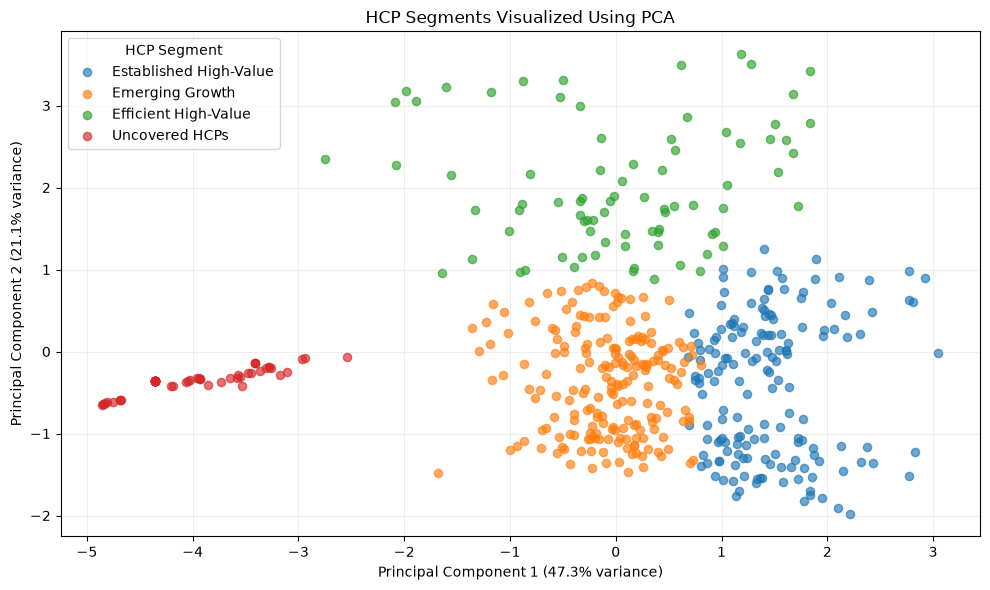

In [16]:
pca = PCA(n_components=2)


pca_coordinates = pca.fit_transform(
    X_scaled
)


pca_plot_data = segmented_hcps[
    [
        "hcp_id",
        "hcp_segment",
    ]
].copy()


pca_plot_data["principal_component_1"] = (
    pca_coordinates[:, 0]
)

pca_plot_data["principal_component_2"] = (
    pca_coordinates[:, 1]
)


explained_variance = (
    pca.explained_variance_ratio_
    * 100
)


print(
    "Variance explained by PC1:",
    round(explained_variance[0], 2),
    "%"
)

print(
    "Variance explained by PC2:",
    round(explained_variance[1], 2),
    "%"
)

print(
    "Total variance shown in the chart:",
    round(explained_variance.sum(), 2),
    "%"
)


plt.figure(figsize=(10, 6))


for segment in pca_plot_data[
    "hcp_segment"
].unique():

    segment_data = pca_plot_data[
        pca_plot_data["hcp_segment"] == segment
    ]

    plt.scatter(
        segment_data["principal_component_1"],
        segment_data["principal_component_2"],
        label=segment,
        alpha=0.65,
        s=35
    )


plt.xlabel(
    f"Principal Component 1 "
    f"({explained_variance[0]:.1f}% variance)"
)

plt.ylabel(
    f"Principal Component 2 "
    f"({explained_variance[1]:.1f}% variance)"
)

plt.title(
    "HCP Segments Visualized Using PCA"
)

plt.legend(
    title="HCP Segment"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [17]:
plt.savefig(
    OUTPUT_DIR / "hcp_segments_pca.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [18]:
final_hcp_path = (
    OUTPUT_DIR
    / "hcp_segmentation_results.csv"
)

segment_summary_path = (
    OUTPUT_DIR
    / "hcp_segment_summary.csv"
)

priority_summary_path = (
    OUTPUT_DIR
    / "hcp_priority_summary.csv"
)

cluster_evaluation_path = (
    OUTPUT_DIR
    / "cluster_evaluation.csv"
)


segmented_hcps.to_csv(
    final_hcp_path,
    index=False
)

final_business_profile.to_csv(
    segment_summary_path,
    index=False
)

priority_summary.to_csv(
    priority_summary_path,
    index=False
)

cluster_evaluation.to_csv(
    cluster_evaluation_path,
    index=False
)


export_summary = pd.DataFrame(
    {
        "file": [
            final_hcp_path.name,
            segment_summary_path.name,
            priority_summary_path.name,
            cluster_evaluation_path.name,
            "hcp_segments_pca.png",
        ],
        "purpose": [
            "HCP-level features, segments, scores and actions",
            "Summary profile and strategy for each segment",
            "Priority-tier summary within each segment",
            "K-Means model-selection results",
            "PCA visualization of the four HCP segments",
        ],
    }
)


print(
    "HCP rows exported:",
    len(segmented_hcps)
)

print(
    "Unique HCPs exported:",
    segmented_hcps["hcp_id"].nunique()
)

print(
    "Missing segment assignments:",
    segmented_hcps["hcp_segment"]
    .isna()
    .sum()
)

print(
    "Missing opportunity scores:",
    segmented_hcps["opportunity_score"]
    .isna()
    .sum()
)

print(
    "Output folder:",
    OUTPUT_DIR
)


display(export_summary)

HCP rows exported: 500
Unique HCPs exported: 500
Missing segment assignments: 0
Missing opportunity scores: 0
Output folder: D:\rxguide\rxguide-hcp-analytics\outputs


,file,purpose
0,hcp_segmentation_results.csv,"HCP-level features, segments, scores and actions"
1,hcp_segment_summary.csv,Summary profile and strategy for each segment
2,hcp_priority_summary.csv,Priority-tier summary within each segment
3,cluster_evaluation.csv,K-Means model-selection results
4,hcp_segments_pca.png,PCA visualization of the four HCP segments
